**Proyecto final - Clasificador de riesgo bancario**

Integrantes:

- Sergio Godoy
- Rodrigo Mercado

In [ ]:
# ---
# CLASIFICADOR DE RIESGO BANCARIO CON PYCARET
# ---

# ---
# INSTALACIÓN DE PYCARET EN COLAB
# ---
!pip uninstall -y pycaret
!pip install -U "git+https://github.com/pycaret/pycaret.git@master"

# Reiniciar runtime después de esta instalación
print("¡REINICIA EL RUNTIME AHORA! (Runtime -> Restart session)")

Found existing installation: pycaret 3.4.0
Uninstalling pycaret-3.4.0:
  Successfully uninstalled pycaret-3.4.0
  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-bw2s8ghw
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-bw2s8ghw
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycaret: filename=pycaret-3.4.0-py3-none-any.whl size=491177 sha256=4291fc22fb896cdb2747fcd1d340a8af0508f157fb9fcc02716e5f864be51e8d
  Stored in directory: /tmp/pip-ephem-wheel-cache-idh7u5ji/wheels/99/89/3c/c7c5eeb0c1b55b58e842d6a342a2b58abd4a60e0d40d750b74
Successfully built pycaret


ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.1 (from versions:

KeyboardInterrupt: 

In [ ]:
# ---
# CLASIFICADOR DE RIESGO BANCARIO - PYCARET CON VISUALIZACIONES COMPLETAS
# ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Imports de PyCaret
from pycaret.classification import *

print("✅ PyCaret y librerías importadas correctamente")


✅ PyCaret y librerías importadas correctamente


In [ ]:
# ---
# 1) CARGA DE DATOS (Colab) - SE DEBE SELECCIONAR EL ARCHIVO (ABAJO)
# ---
from google.colab import files

def cargar_archivo():
    uploaded = files.upload()
    if not uploaded:
        print(" No se cargó ningún archivo. Sube un .xlsx.")
        return None
    xlsx_path = list(uploaded.keys())[0]
    print(f" Archivo cargado: {xlsx_path}")
    return xlsx_path

xlsx_path = cargar_archivo()
if xlsx_path is None:
    raise SystemExit("Se requiere un archivo .xlsx para continuar.")

xls = pd.ExcelFile(xlsx_path)
print(" Hojas disponibles:", xls.sheet_names)


Saving DPrueba4.xlsx to DPrueba4 (4).xlsx
 Archivo cargado: DPrueba4 (4).xlsx
 Hojas disponibles: ['IndiceMora', 'CoberturaMoraPrevisiones', 'RatioLiquidez', 'ROA', 'ROE', 'Activos', 'Patrimonio', 'CarteraDepositos', 'PatrimonioActivo', 'CrecimientoCarteraEntidad', 'CrecimientoCarteraSistema', 'PrevisionesActivo', 'CAP', 'DepMayorista']


In [ ]:
# ---
# 2) CONFIGURACIÓN PARA CARGAR EL ARCHIVO ADECUADAMENTE
# ---
MES_MAP = {
    'ENERO':1,'FEBRERO':2,'MARZO':3,'ABRIL':4,'MAYO':5,'JUNIO':6,
    'JULIO':7,'AGOSTO':8,'SEPTIEMBRE':9,'OCTUBRE':10,'NOVIEMBRE':11,'DICIEMBRE':12
}

VARIABLES_ESPERADAS = [
    'IndiceMora','CoberturaMoraPrevisiones','Ratioliquidez','ROA','ROE',
    'Activos','Patrimonio','CarteraDepositos','PatrimonioActivo',
    'CrecimientoCarteraEntidad','CrecimientoCarteraSistema','PrevisionesActivo','CAP'
]

In [ ]:
# ---
# 3) FUNCIONES DE PREPROCESAMIENTO Y EDA COMPLETO
# ---
def detectar_encabezado(hoja, archivo_excel, max_intentos=6):
    for intento in range(max_intentos):
        try:
            df_temp = pd.read_excel(archivo_excel, sheet_name=hoja, header=intento)
            if 'Año' in df_temp.columns and 'Mes' in df_temp.columns:
                return intento
        except Exception:
            continue
    return 0

def limpiar_hoja_banco(hoja, archivo_excel):
    try:
        fila_encabezado = detectar_encabezado(hoja, archivo_excel)
        df = pd.read_excel(archivo_excel, sheet_name=hoja, header=fila_encabezado)
        df.columns = [str(col).strip() for col in df.columns]
        if 'TotalBancos' in df.columns:
            return None
        df['Mes'] = df['Mes'].astype(str).str.upper().str.strip()
        df['Mes_num'] = df['Mes'].map(MES_MAP)
        df['fecha'] = pd.to_datetime({'year': df['Año'], 'month': df['Mes_num'], 'day': 1}, errors='coerce')
        columns_no_banco = ['Año','Mes','Mes_num','fecha','TotalBancos','Total Sistema']
        columns_banco = [c for c in df.columns if c not in columns_no_banco]
        if len(columns_banco) == 0:
            return None
        df_largo = df.melt(id_vars=['Año','Mes','fecha'], value_vars=columns_banco,
                          var_name='banco', value_name=hoja)
        df_largo[hoja] = pd.to_numeric(df_largo[hoja], errors='coerce')
        df_largo = df_largo.dropna(subset=['fecha','banco'])
        return df_largo[['banco','fecha', hoja]]
    except Exception as e:
        print(f" x Error procesando hoja {hoja}: {e}")
        return None

def limpiar_hoja_sistema(archivo_excel):
    hoja = 'CrecimientoCarteraSistema'
    if hoja not in xls.sheet_names:
        return None
    try:
        fila_encabezado = detectar_encabezado(hoja, archivo_excel)
        df = pd.read_excel(archivo_excel, sheet_name=hoja, header=fila_encabezado)
        df.columns = [str(col).strip() for col in df.columns]
        df['Mes'] = df['Mes'].astype(str).str.upper().str.strip()
        df['Mes_num'] = df['Mes'].map(MES_MAP)
        df['fecha'] = pd.to_datetime({'year': df['Año'], 'month': df['Mes_num'], 'day': 1}, errors='coerce')
        out = (df[['fecha','TotalBancos']]
               .rename(columns={'TotalBancos':'CrecimientoCarteraSistema'})
               .dropna(subset=['fecha']))
        return out
    except Exception as e:
        print(f" x Error procesando {hoja}: {e}")
        return None

def crear_panel_completo(archivo_excel, variables):
    datos = []
    for var in variables:
        if var == 'CrecimientoCarteraSistema':
            continue
        if var in xls.sheet_names:
            print(f" !! Procesando: {var}")
            dfl = limpiar_hoja_banco(var, archivo_excel)
            if dfl is not None:
                datos.append(dfl)
        else:
            print(f" !! Hoja no encontrada: {var}")
    if not datos:
        print(" !! No se pudieron cargar hojas por banco")
        return None

    panel = datos[0]
    for dfv in datos[1:]:
        panel = panel.merge(dfv, on=['banco','fecha'], how='outer')

    crec_sis = limpiar_hoja_sistema(archivo_excel)
    if crec_sis is not None:
        panel = panel.merge(crec_sis, on='fecha', how='left')

    panel = panel.sort_values(['banco','fecha']).reset_index(drop=True)
    print(f"🔴 Panel creado: {panel.shape[0]} filas, {panel.shape[1]} columnas")
    return panel

In [ ]:
# ---
# 4) EDA COMPLETO CON GRÁFICOS
# ---
def analisis_exploratorio_completo(panel):
    """
    Análisis exploratorio completo con todas las visualizaciones
    """
    print("\n" + "="*60)
    print("ANÁLISIS EXPLORATORIO COMPLETO DE DATOS")
    print("="*60)
    print(f"Período: {panel['fecha'].min().date()} -> {panel['fecha'].max().date()}")
    print(f"Bancos: {panel['banco'].nunique()}")

    # Variables numéricas
    vars_num = panel.select_dtypes(include=[np.number]).columns.tolist()
    print(f"Variables numéricas: {len(vars_num)}")

    # 1. ANÁLISIS DE VALORES FALTANTES
    print("\n📊 1. ANÁLISIS DE VALORES FALTANTES")
    falt = panel[vars_num].isna().mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    falt[falt > 0].plot(kind='bar', color='coral')
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.ylabel('Porcentaje Faltante')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. ESTADÍSTICOS DESCRIPTIVOS
    print("\n📈 2. ESTADÍSTICOS DESCRIPTIVOS")
    display(panel[vars_num].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T)

    # 3. MATRIZ DE CORRELACIÓN
    print("\n🔗 3. MATRIZ DE CORRELACIÓN")
    corr = panel[vars_num].corr()
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
                square=True, cbar_kws={"shrink": .8})
    plt.title('Matriz de Correlación entre Variables')
    plt.tight_layout()
    plt.show()

    # 4. DISTRIBUCIONES DE VARIABLES
    print("\n📊 4. DISTRIBUCIONES DE VARIABLES")
    ncols = 3
    nrows = int(np.ceil(len(vars_num)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    axes = axes.flatten()

    for i, v in enumerate(vars_num):
        if i < len(axes):
            sns.histplot(panel[v], bins=30, kde=True, ax=axes[i], color='skyblue')
            axes[i].set_title(f'Distribución: {v}')
            axes[i].set_xlabel('')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # 5. SERIES TEMPORALES (MEDIA POR FECHA)
    print("\n📈 5. EVOLUCIÓN TEMPORAL (MEDIA DEL SISTEMA)")
    dfm = panel.groupby('fecha')[vars_num].mean().reset_index()

    ncols = 2
    nrows = int(np.ceil(len(vars_num)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    axes = axes.flatten()

    for i, v in enumerate(vars_num):
        if i < len(axes):
            axes[i].plot(dfm['fecha'], dfm[v], lw=2, color='green', alpha=0.7)
            axes[i].set_title(f'Evolución Temporal: {v}')
            axes[i].set_xlabel('Fecha')
            axes[i].tick_params(axis='x', rotation=45)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # 6. ANÁLISIS POR BANCO (BOXPLOTS)
    print("\n🏦 6. DISTRIBUCIÓN POR BANCO (TOP 6 VARIABLES)")
    # Seleccionar las 6 variables más importantes
    vars_importantes = ['IndiceMora', 'CAP', 'Ratioliquidez', 'ROA', 'ROE', 'Activos']
    vars_plot = [v for v in vars_importantes if v in vars_num][:6]

    ncols = 2
    nrows = 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))
    axes = axes.flatten()

    for i, v in enumerate(vars_plot):
        if i < len(axes):
            # Tomar muestra de bancos si hay muchos
            bancos_unicos = panel['banco'].unique()
            if len(bancos_unicos) > 10:
                bancos_muestra = np.random.choice(bancos_unicos, 10, replace=False)
                data_plot = panel[panel['banco'].isin(bancos_muestra)]
            else:
                data_plot = panel

            sns.boxplot(data=data_plot, x='banco', y=v, ax=axes[i])
            axes[i].set_title(f'Distribución de {v} por Banco')
            axes[i].set_xlabel('')
            axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return vars_num

def crear_variables_derivadas(panel):
    df = panel.copy()

    if {'Activos','Patrimonio'}.issubset(df.columns):
        with np.errstate(divide='ignore', invalid='ignore'):
            df['Leverage'] = df['Activos'] / df['Patrimonio']
        print("☑ Leverage")
    if 'Activos' in df.columns:
        with np.errstate(divide='ignore'):
            df['Size'] = np.log(df['Activos'].replace(0, np.nan))
        print("☑ Size")
    if {'CrecimientoCarteraEntidad','CrecimientoCarteraSistema'}.issubset(df.columns):
        df['GapCrecimiento'] = df['CrecimientoCarteraEntidad'] - df['CrecimientoCarteraSistema']
        print("☑ GapCrecimiento")
    if 'CarteraDepositos' in df.columns:
        df['LDR'] = df['CarteraDepositos']
        print("☑ LDR")
    return df

def construir_score(panel):
    df = panel.copy()
    comps = []

    def zcol(s):
        m, st = np.nanmean(s), np.nanstd(s)
        return (s - m) / st if (st and st > 0) else pd.Series(np.nan, index=s.index)

    if 'IndiceMora' in df.columns: comps.append(zcol(df['IndiceMora']))
    if 'PrevisionesActivo' in df.columns: comps.append(zcol(df['PrevisionesActivo']))
    if 'Leverage' in df.columns: comps.append(zcol(df['Leverage']))
    if 'Ratioliquidez' in df.columns: comps.append(-zcol(df['Ratioliquidez']))
    if 'CoberturaMoraPrevisiones' in df.columns: comps.append(zcol(df['CoberturaMoraPrevisiones']))
    if 'CAP' in df.columns: comps.append(-zcol(df['CAP']))

    if len(comps) == 0:
        raise ValueError("No hay variables suficientes para el score.")

    df['score_riesgo'] = np.nanmean(np.vstack([c.values for c in comps]), axis=0)
    return df

def clasificar_riesgo_con_umbral(df, q20, q40, q60, q80):
    out = df.copy()

    def asignar_class(s):
        if np.isnan(s): return np.nan
        return 0 if s <= q20 else 1 if s <= q40 else 2 if s <= q60 else 3 if s <= q80 else 4

    out['clase_riesgo'] = out['score_riesgo'].apply(asignar_class).astype('Int64')

    if 'CAP' in out.columns:
        m = out['CAP'] < 0.11
        out.loc[m & out['clase_riesgo'].notna(), 'clase_riesgo'] = np.maximum(out.loc[m, 'clase_riesgo'], 3)
    if 'Ratioliquidez' in out.columns:
        m = out['Ratioliquidez'] < 0.40
        out.loc[m & out['clase_riesgo'].notna(), 'clase_riesgo'] = np.maximum(out.loc[m, 'clase_riesgo'], 3)
    return out

def split_temporal_y_etiquetar(panel):
    df = panel.copy()
    df['anio'] = df['fecha'].dt.year
    anio_max = int(df['anio'].max())
    train_mask, test_mask = df['anio'] < anio_max, df['anio'] == anio_max

    q20, q40, q60, q80 = np.nanpercentile(df.loc[train_mask, 'score_riesgo'], [20,40,60,80])

    df_train = clasificar_riesgo_con_umbral(df.loc[train_mask], q20, q40, q60, q80)
    df_test = clasificar_riesgo_con_umbral(df.loc[test_mask], q20, q40, q60, q80)
    df_out = pd.concat([df_train, df_test]).sort_index()

    vars_candidatas = [
        'IndiceMora','CoberturaMoraPrevisiones','Ratioliquidez','ROA','ROE','Activos','Patrimonio',
        'CarteraDepositos','PatrimonioActivo','CrecimientoCarteraEntidad','CrecimientoCarteraSistema',
        'PrevisionesActivo','CAP','Leverage','Size','GapCrecimiento','LDR'
    ]

    feats = [v for v in vars_candidatas if v in df_out.columns and pd.api.types.is_numeric_dtype(df_out[v])]

    X_train = df_out.loc[train_mask, feats]
    y_train = df_out.loc[train_mask, 'clase_riesgo'].astype(int)
    X_test = df_out.loc[test_mask, feats]
    y_test = df_out.loc[test_mask, 'clase_riesgo'].astype(int)

    print(f" ⬇ Cortes fijos (train): {q20:.3f}, {q40:.3f}, {q60:.3f}, {q80:.3f}")
    print("Distribución de clases (train):"); print(y_train.value_counts().sort_index())
    print("Distribución de clases (test):"); print(y_test.value_counts().sort_index())

    return df_out, X_train, X_test, y_train, y_test, feats

In [ ]:
# ---
# 5) VISUALIZACIONES PYCARET COMPLETAS
# ---
def generar_visualizaciones_pycaret(modelo_final):
    """
    Genera todas las visualizaciones de PyCaret
    """
    print("\n📊 GENERANDO VISUALIZACIONES PYCARET")

    # 1. MATRIZ DE CONFUSIÓN
    try:
        print("📈 1. Matriz de Confusión")
        plot_model(modelo_final, plot='confusion_matrix', save=False)
        plt.title('Matriz de Confusión - Modelo Final', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️  Error en matriz de confusión: {e}")

    # 2. CURVA AUC
    try:
        print("📈 2. Curva AUC")
        plot_model(modelo_final, plot='auc', save=False)
        plt.title('Curva ROC AUC - Modelo Final', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️  Error en curva AUC: {e}")

    # 3. IMPORTANCIA DE CARACTERÍSTICAS
    try:
        print("📈 3. Importancia de Características")
        plot_model(modelo_final, plot='feature', save=False)
        plt.title('Importancia de Características - Modelo Final', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️  Error en importancia de características: {e}")

    # 4. CURVA DE PRECISIÓN-RECALL
    try:
        print("📈 4. Curva Precisión-Recall")
        plot_model(modelo_final, plot='pr', save=False)
        plt.title('Curva Precisión-Recall - Modelo Final', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️  Error en curva PR: {e}")

    # 5. CURVA DE APRENDIZAJE
    try:
        print("📈 5. Curva de Aprendizaje")
        plot_model(modelo_final, plot='learning', save=False)
        plt.title('Curva de Aprendizaje - Modelo Final', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️  Error en curva de aprendizaje: {e}")

    # 6. GRÁFICO DE CLASIFICACIÓN
    try:
        print("📈 6. Reporte de Clasificación")
        plot_model(modelo_final, plot='class_report', save=False)
        plt.title('Reporte de Clasificación - Modelo Final', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️  Error en reporte de clasificación: {e}")


In [ ]:
# ---
# 6) MAPA DE CALOR DE RIESGO (como en el original)
# ---
def crear_mapa_calor_riesgo(panel, ventana_anios=5):
    """
    Crea el mapa de calor de riesgo bancario
    """
    print("\n🔥 GENERANDO MAPA DE CALOR DE RIESGO")

    from matplotlib.colors import LinearSegmentedColormap

    def risk_cmap_bright_yellow():
        stops = [
            "#6FC435",  # verde fuerte
            "#67FF00",  # verde claro
            "#FFFF99",  # amarillo MUV claro (centro)
            "#FFBB00",  # naranja
            "#FF0505"   # rojo intenso
        ]
        return LinearSegmentedColormap.from_list("risk_bright_yellow", stops, N=512)

    panel = panel.copy()
    panel['fecha'] = pd.to_datetime(panel['fecha'])
    max_f = panel['fecha'].max()
    cutoff = max_f - pd.DateOffset(years=ventana_anios)
    df_last = panel[panel['fecha'] >= cutoff].copy()

    if 'score_riesgo' not in panel.columns:
        raise ValueError("'score_riesgo' no existe en el DataFrame.")

    # Crear heatmap
    H_score = (df_last.pivot_table(index='banco', columns='fecha', values='score_riesgo', aggfunc='mean')
               .sort_index()
               .reindex(sorted(df_last['fecha'].unique()), axis=1)
               .apply(pd.to_numeric, errors='coerce')
               .astype(float))

    if H_score.empty:
        print("▲ No hay datos suficientes para el heatmap.")
        return

    # Normalizar
    s_min, s_max = np.nanmin(H_score.values), np.nanmax(H_score.values)
    rng = (s_max - s_min) if np.isfinite(s_max - s_min) and (s_max > s_min) else 1.0
    H_norm = (H_score - s_min) / rng

    # Configurar colores y etiquetas
    seg_edges = np.linspace(0.0, 1.0, 6)
    tick_centers = (seg_edges[:-1] + seg_edges[1:]) / 2.0
    tick_labels = ['Muy Bajo (0)', 'Bajo (1)', 'Medio (2)', 'Alto (3)', 'Muy Alto (4)']
    cmap = risk_cmap_bright_yellow()

    # Crear figura
    fig, ax = plt.subplots(figsize=(14, 9))
    im = ax.imshow(H_norm.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)

    ax.set_title(f'Mapa de Calor - Score de Riesgo Bancario (últimos {ventana_anios} años)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Fecha', fontsize=12)
    ax.set_ylabel('Banco', fontsize=12)

    # Configurar ejes
    ax.set_xticks(range(len(H_norm.columns)))
    ax.set_xticklabels([pd.to_datetime(c).strftime('%Y-%m') for c in H_norm.columns],
                       rotation=90, fontsize=8)
    ax.set_yticks(range(len(H_norm.index)))
    ax.set_yticklabels(H_norm.index, fontsize=9)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks(tick_centers.tolist())
    cbar.set_ticklabels(tick_labels)
    cbar.set_label('Nivel de Riesgo', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.show()


In [ ]:
# ---
# 7) PYCARET COMPLETO
# ---
def ejecutar_pycaret_completo(X_train, y_train, X_test, y_test):
    """
    Ejecuta PyCaret con todas las funcionalidades
    """
    print("🚀 INICIANDO PYCARET COMPLETO")

    # Preparar datos
    train_data = X_train.copy()
    train_data['target'] = y_train.values

    test_data = X_test.copy()
    test_data['target'] = y_test.values

    print("📊 Configurando PyCaret...")

    # SETUP
    try:
        setup_clf = setup(
            data=train_data,
            target='target',
            test_data=test_data,
            session_id=42,
            normalize=True,
            transformation=False,  # Desactivar transformación para evitar problemas
            fix_imbalance=True,
            fold_strategy='kfold',
            fold=5,
            verbose=True
        )
        print("✅ Setup completado")
    except Exception as e:
        print(f"⚠️  Error en setup: {e}")
        setup_clf = setup(
            data=train_data,
            target='target',
            session_id=42,
            verbose=False
        )

    # COMPARAR MODELOS
    print("🔍 Comparando modelos...")
    best_models = compare_models(
        include=['rf', 'lightgbm', 'gbc', 'lr', 'dt'],
        n_select=3,
        sort='Accuracy',
        verbose=True
    )

    if not isinstance(best_models, list):
        best_models = [best_models]

    # OPTIMIZAR MODELOS
    print("🎯 Optimizando modelos...")
    tuned_models = []
    for model in best_models:
        try:
            tuned = tune_model(model, n_iter=10, optimize='F1')
            tuned_models.append(tuned)
        except:
            tuned_models.append(model)

    # ENSEMBLE
    print("🤝 Creando ensemble...")
    if len(tuned_models) > 1:
        ensemble = blend_models(tuned_models, method='soft', optimize='F1')
        final_model = ensemble
    else:
        final_model = tuned_models[0]

    # EVALUAR
    print("📊 Evaluando modelo final...")
    predictions = predict_model(final_model)

    print("\n" + "="*50)
    print("📈 RESULTADOS FINALES PYCARET")
    print("="*50)
    results = pull()
    print(results)

    # GENERAR VISUALIZACIONES
    generar_visualizaciones_pycaret(final_model)

    # MODELO FINAL
    print("🎯 Finalizando modelo...")
    final_model = finalize_model(final_model)
    save_model(final_model, 'modelo_riesgo_bancario_pycaret')
    print("💾 Modelo guardado: 'modelo_riesgo_bancario_pycaret.pkl'")

    return final_model, predictions


🔍 INICIANDO CLASIFICADOR DE RIESGO BANCARIO COMPLETO
 !! Procesando: IndiceMora
 !! Procesando: CoberturaMoraPrevisiones
 !! Hoja no encontrada: Ratioliquidez
 !! Procesando: ROA
 !! Procesando: ROE
 !! Procesando: Activos
 !! Procesando: Patrimonio
 !! Procesando: CarteraDepositos
 !! Procesando: PatrimonioActivo
 !! Procesando: CrecimientoCarteraEntidad
 !! Procesando: PrevisionesActivo
 !! Procesando: CAP
🔴 Panel creado: 2256 filas, 14 columnas

ANÁLISIS EXPLORATORIO COMPLETO DE DATOS
Período: 2010-01-01 -> 2025-08-01
Bancos: 12
Variables numéricas: 12

📊 1. ANÁLISIS DE VALORES FALTANTES


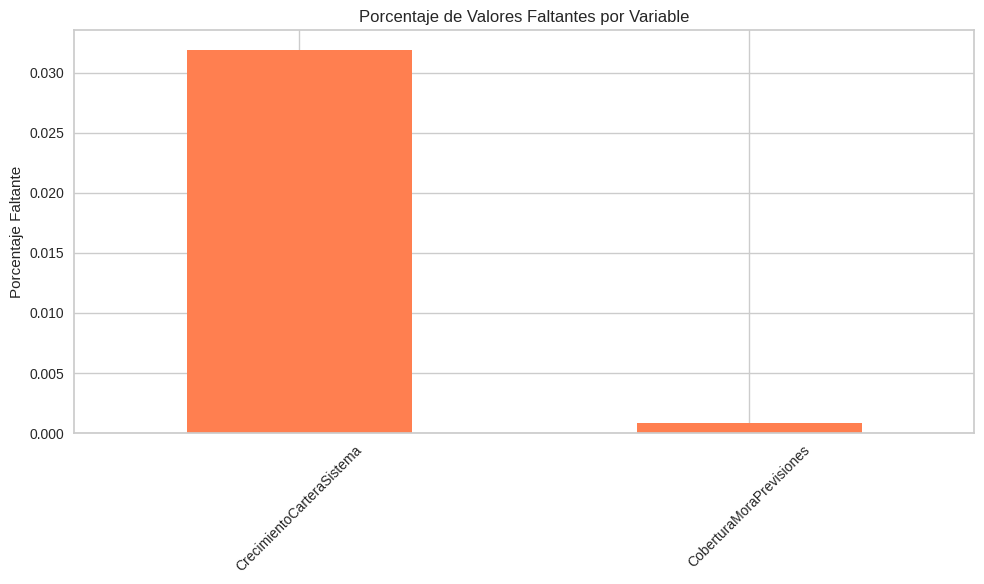


📈 2. ESTADÍSTICOS DESCRIPTIVOS


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
IndiceMora,2256.0,2.006210e-02,1.777284e-02,0.000000e+00,1.226112e-03,3.347886e-03,1.251026e-02,1.733995e-02,2.452552e-02,3.913479e-02,5.928673e-02,2.554430e-01
CoberturaMoraPrevisiones,2254.0,2.025318e+00,1.994121e+00,2.547218e-01,7.994543e-01,9.353916e-01,1.153751e+00,1.558082e+00,2.305185e+00,4.362240e+00,7.292620e+00,4.530890e+01
ROA,2256.0,9.209579e-03,7.181867e-03,-4.123155e-02,-1.366495e-02,1.277686e-03,5.341077e-03,8.529125e-03,1.284050e-02,2.011765e-02,2.672171e-02,8.291120e-02
ROE,2256.0,1.148490e-01,6.508768e-02,-9.452031e-02,-2.843294e-02,5.941989e-03,7.384137e-02,1.137500e-01,1.568425e-01,2.203482e-01,2.847780e-01,3.517781e-01
Activos,2256.0,1.439763e+10,1.131273e+10,1.419571e+08,1.627956e+08,2.073706e+08,5.444674e+09,1.169999e+10,2.113552e+10,3.799029e+10,4.943170e+10,5.606765e+10
Patrimonio,2256.0,1.041372e+09,7.229036e+08,6.062948e+07,8.693910e+07,9.407213e+07,3.994722e+08,9.564378e+08,1.542395e+09,2.368548e+09,2.876547e+09,3.597482e+09
CarteraDepositos,2256.0,9.900036e-01,2.872920e-01,4.149573e-01,5.329740e-01,6.062695e-01,7.838842e-01,9.492260e-01,1.141191e+00,1.531726e+00,1.969113e+00,2.575215e+00
PatrimonioActivo,2256.0,1.106661e-01,1.146969e-01,4.555723e-02,5.299561e-02,5.628379e-02,6.506400e-02,7.399379e-02,9.340759e-02,4.589204e-01,5.649078e-01,6.320260e-01
CrecimientoCarteraEntidad,2256.0,1.313720e-01,1.064774e-01,-3.749135e-01,-1.603745e-01,-1.032207e-02,6.293274e-02,1.215280e-01,1.891763e-01,3.336661e-01,4.061688e-01,5.386134e-01
PrevisionesActivo,2256.0,2.067515e-02,8.855662e-03,1.330914e-03,1.949538e-03,4.036240e-03,1.563685e-02,2.017188e-02,2.605021e-02,3.359869e-02,4.100305e-02,1.016191e-01



🔗 3. MATRIZ DE CORRELACIÓN


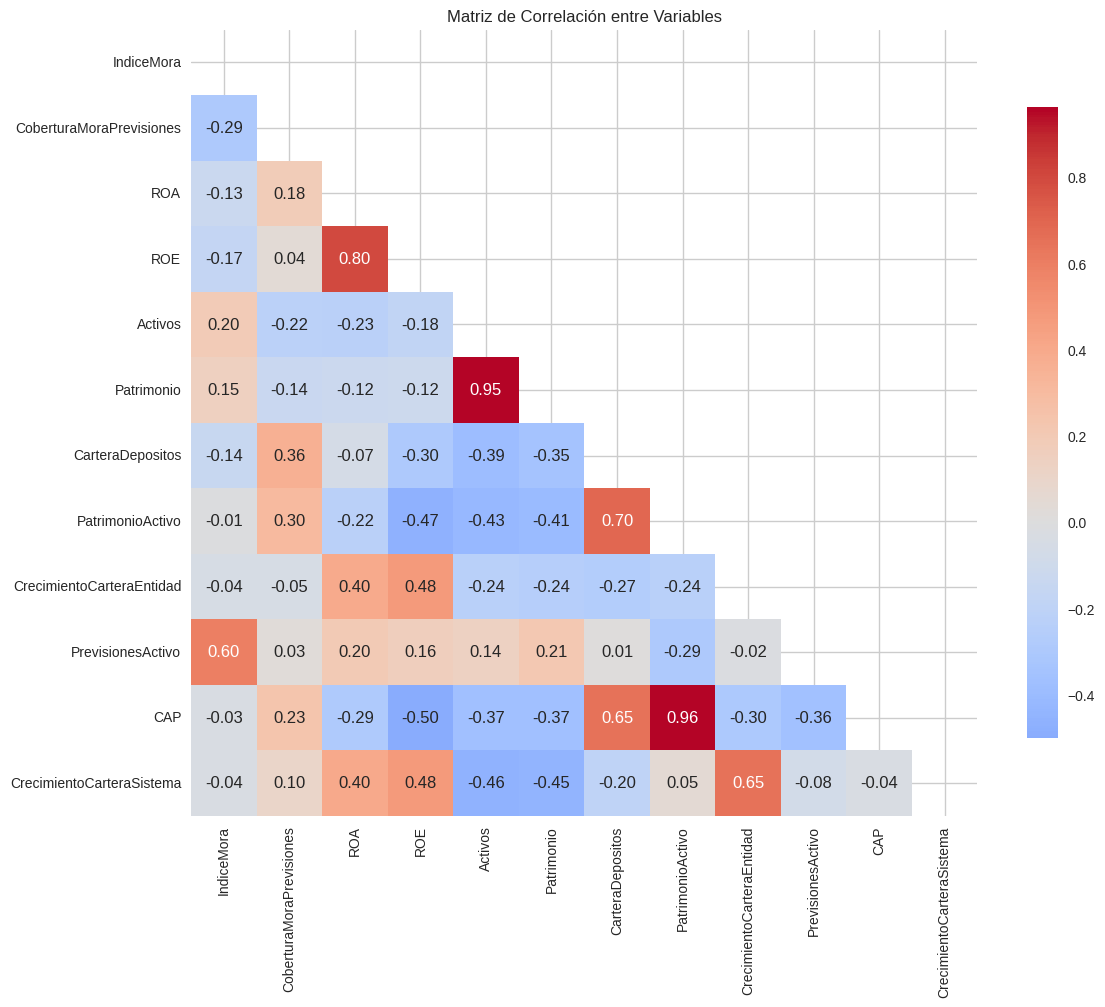


📊 4. DISTRIBUCIONES DE VARIABLES


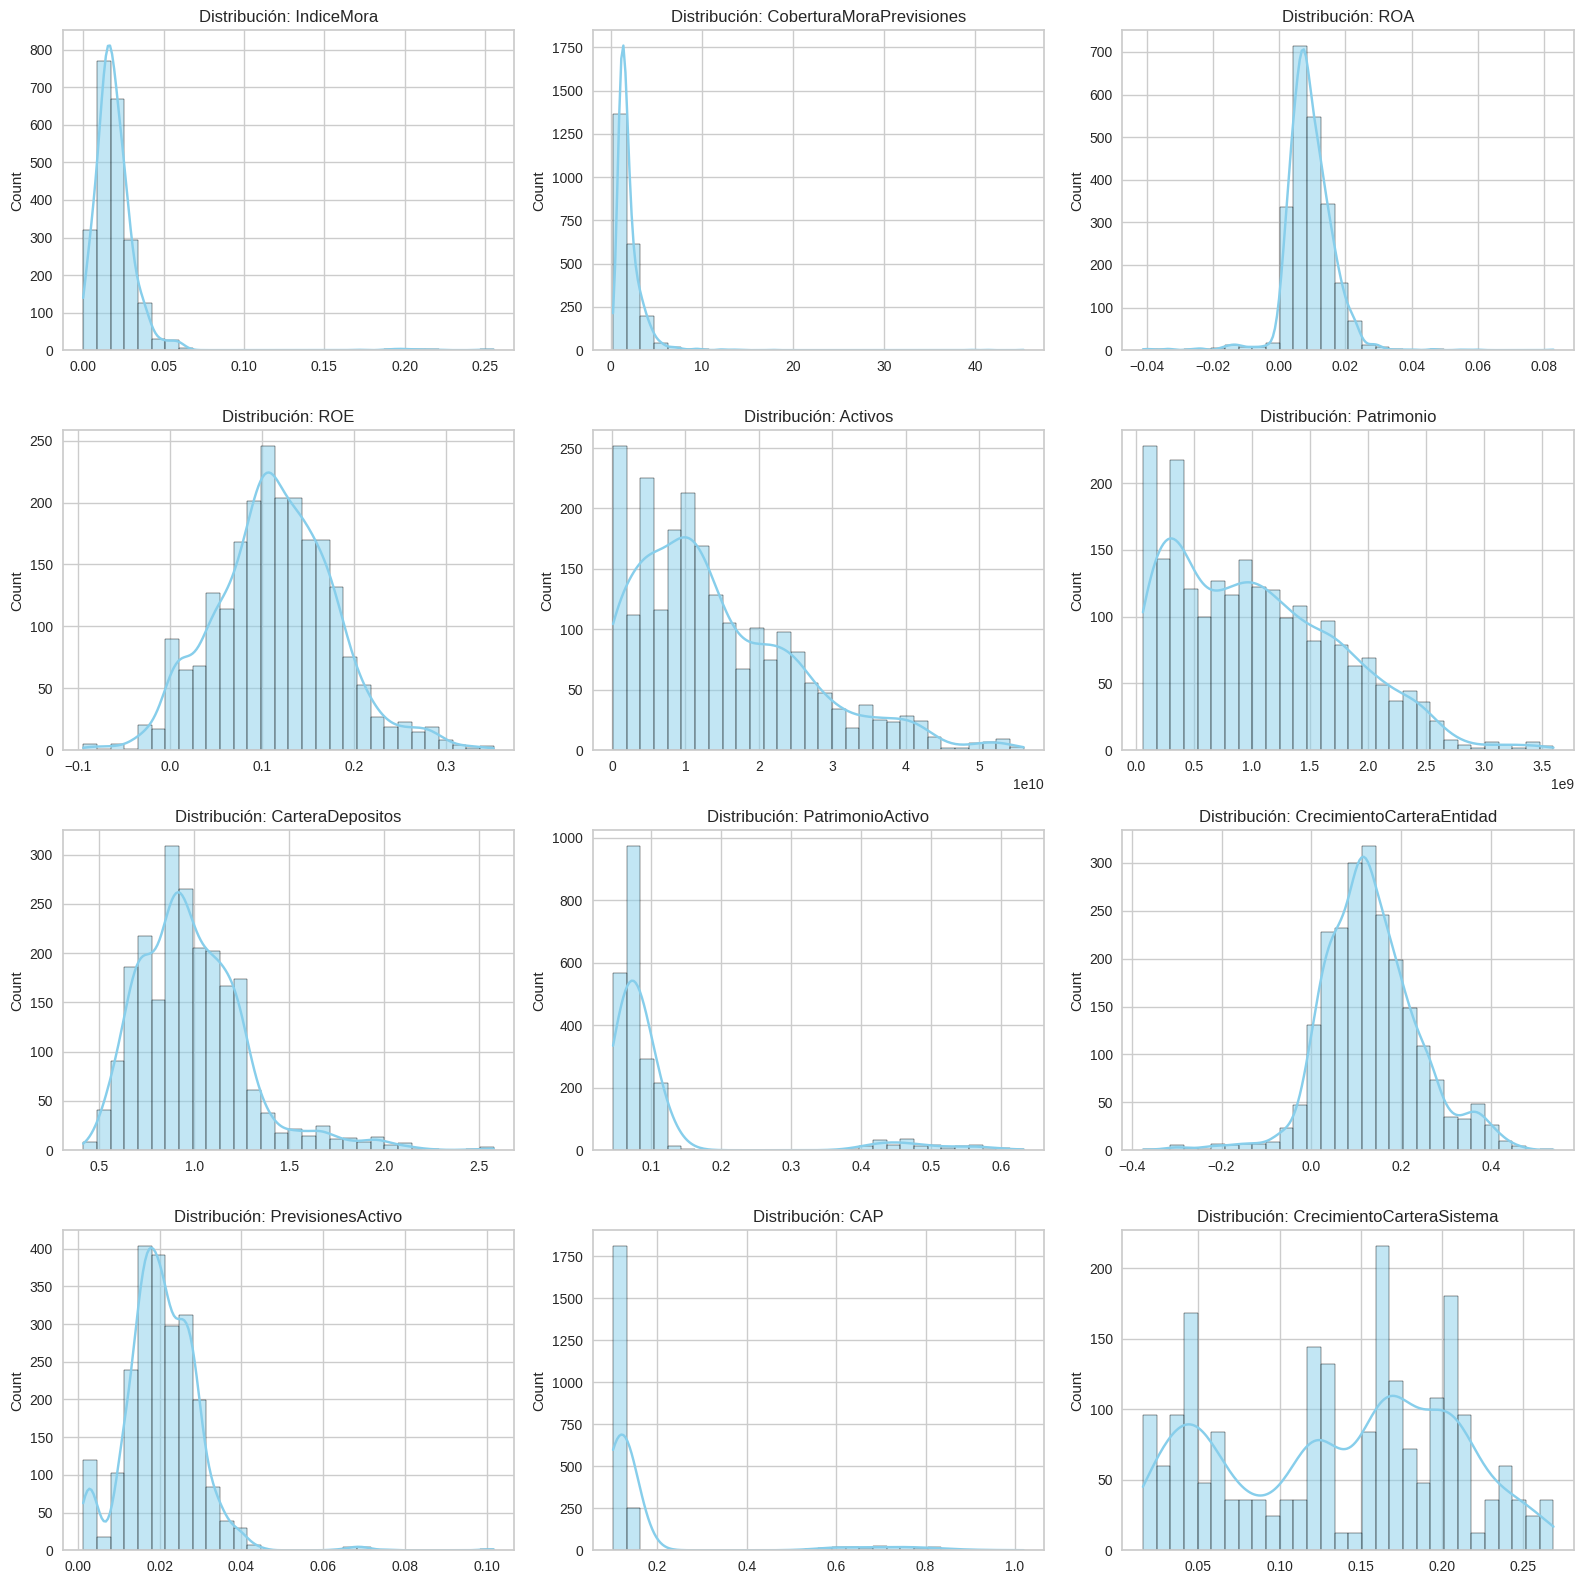


📈 5. EVOLUCIÓN TEMPORAL (MEDIA DEL SISTEMA)


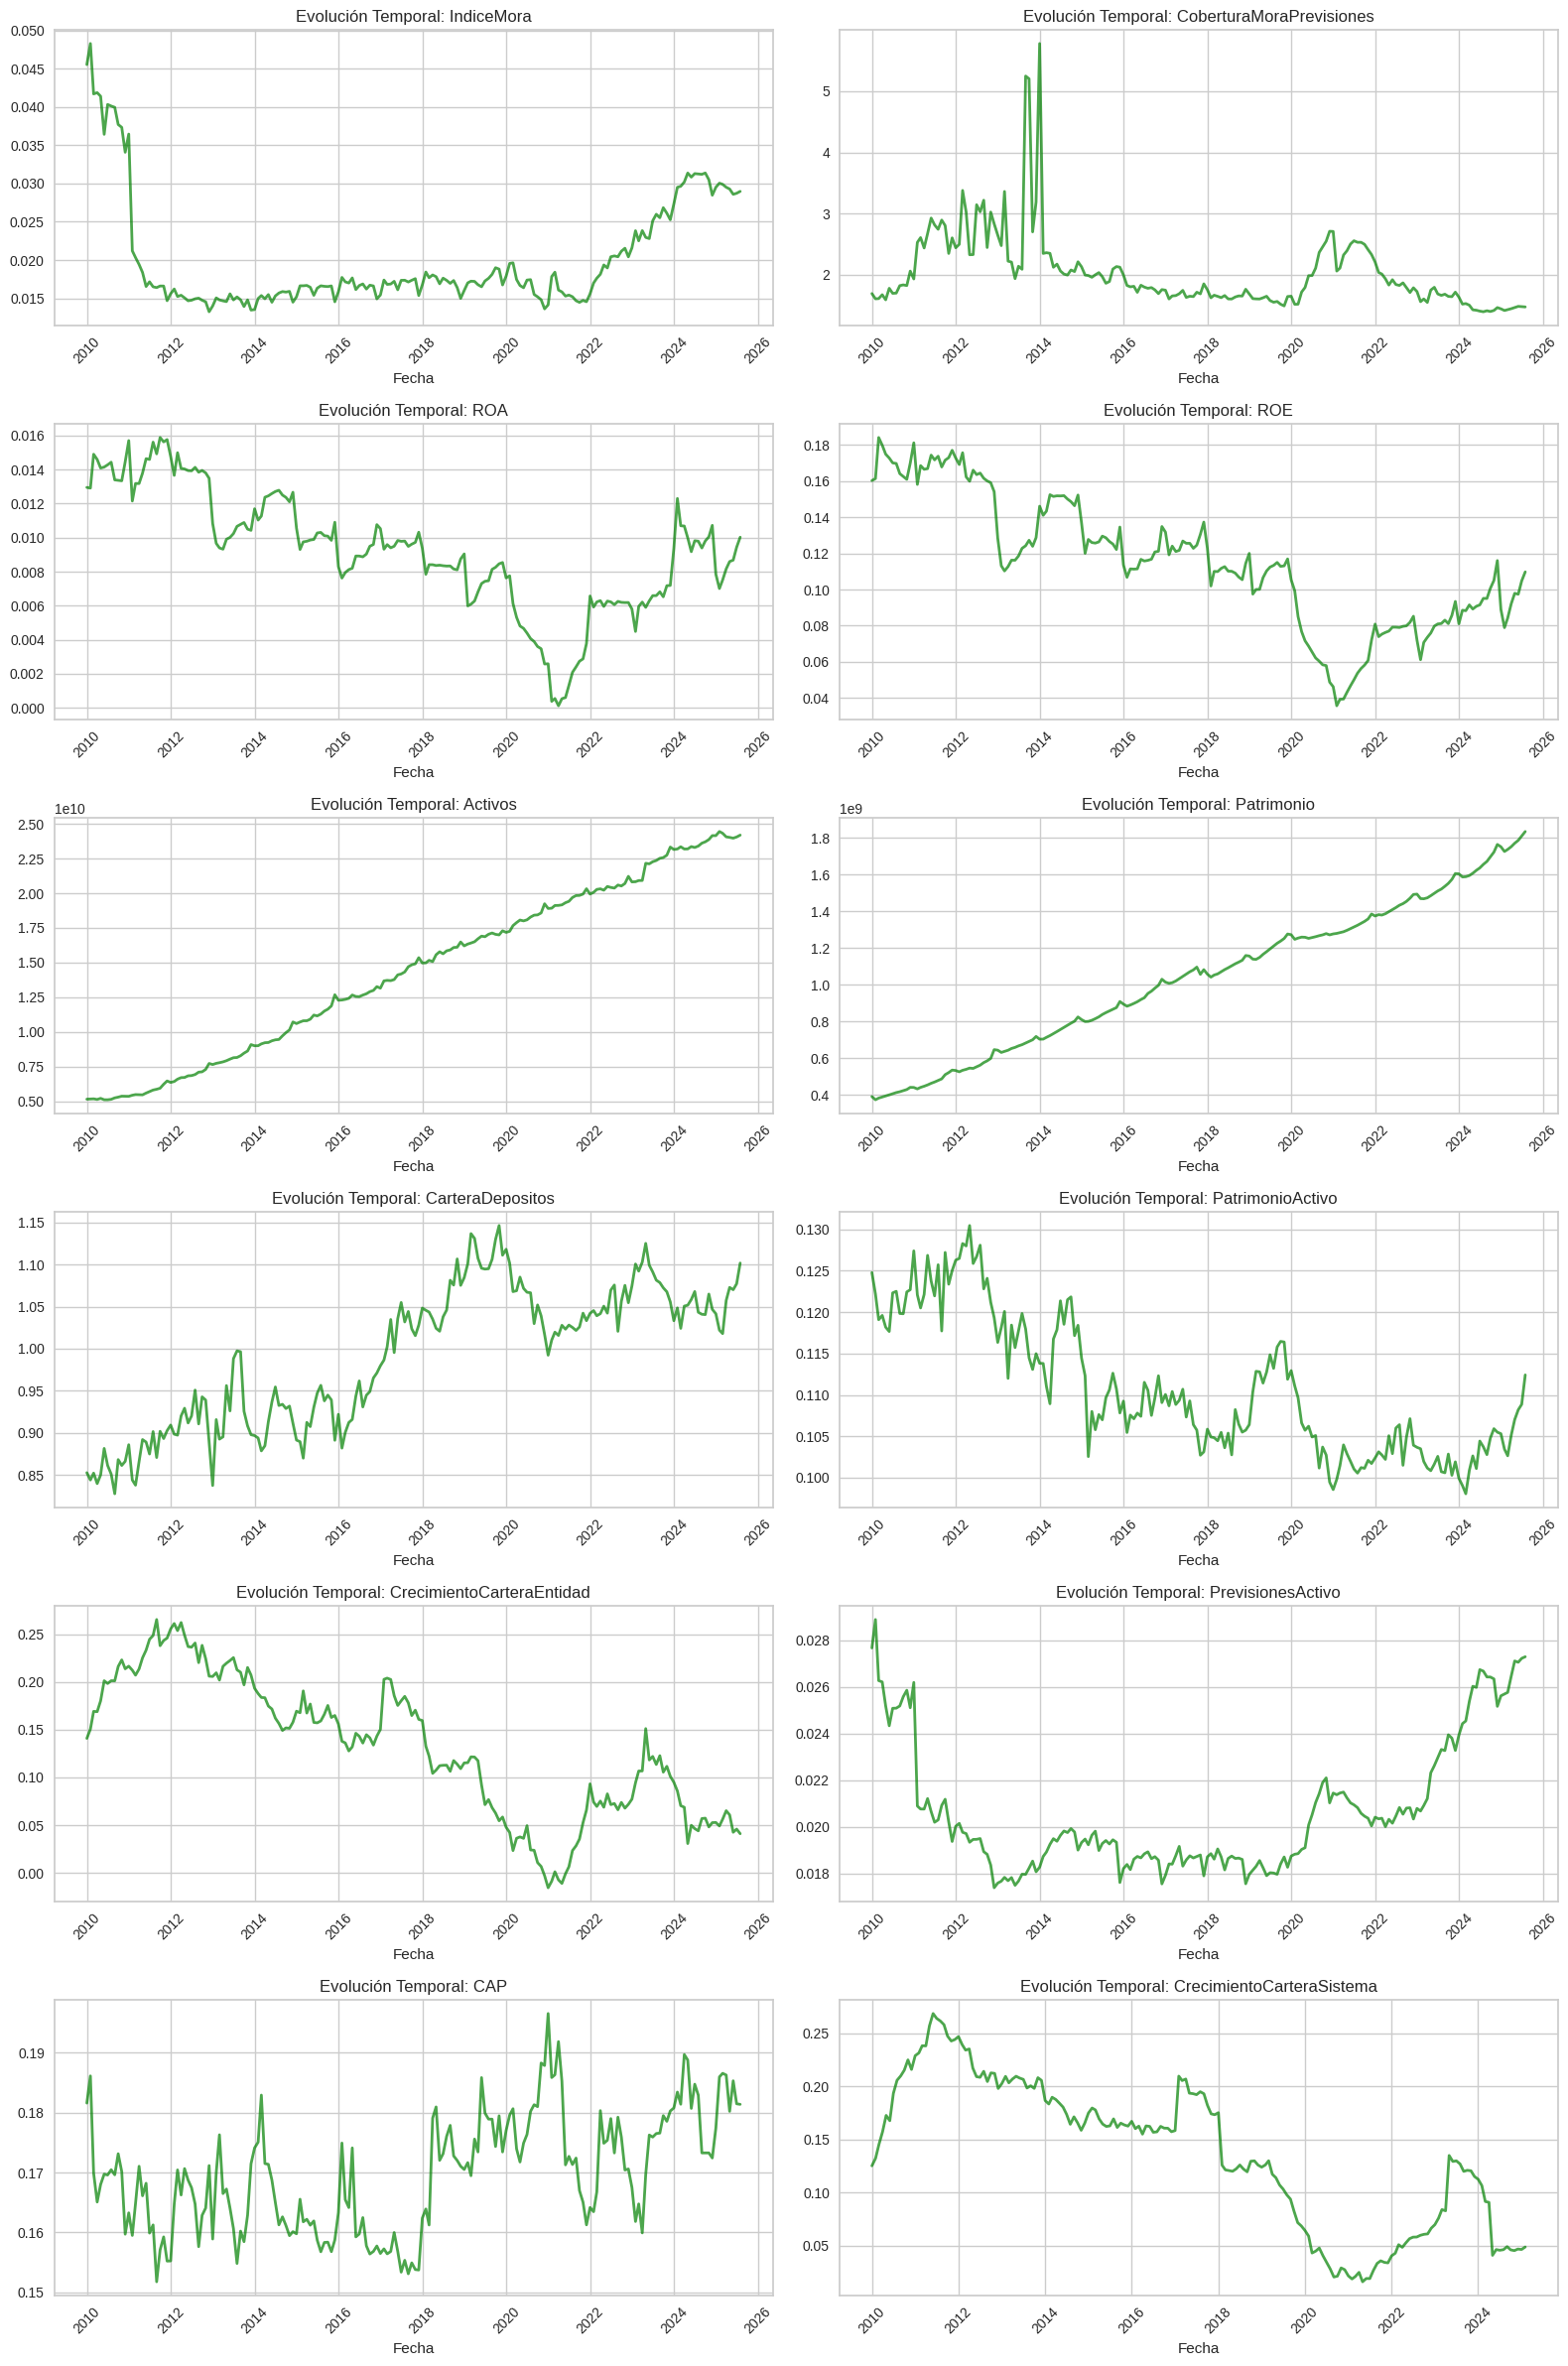


🏦 6. DISTRIBUCIÓN POR BANCO (TOP 6 VARIABLES)


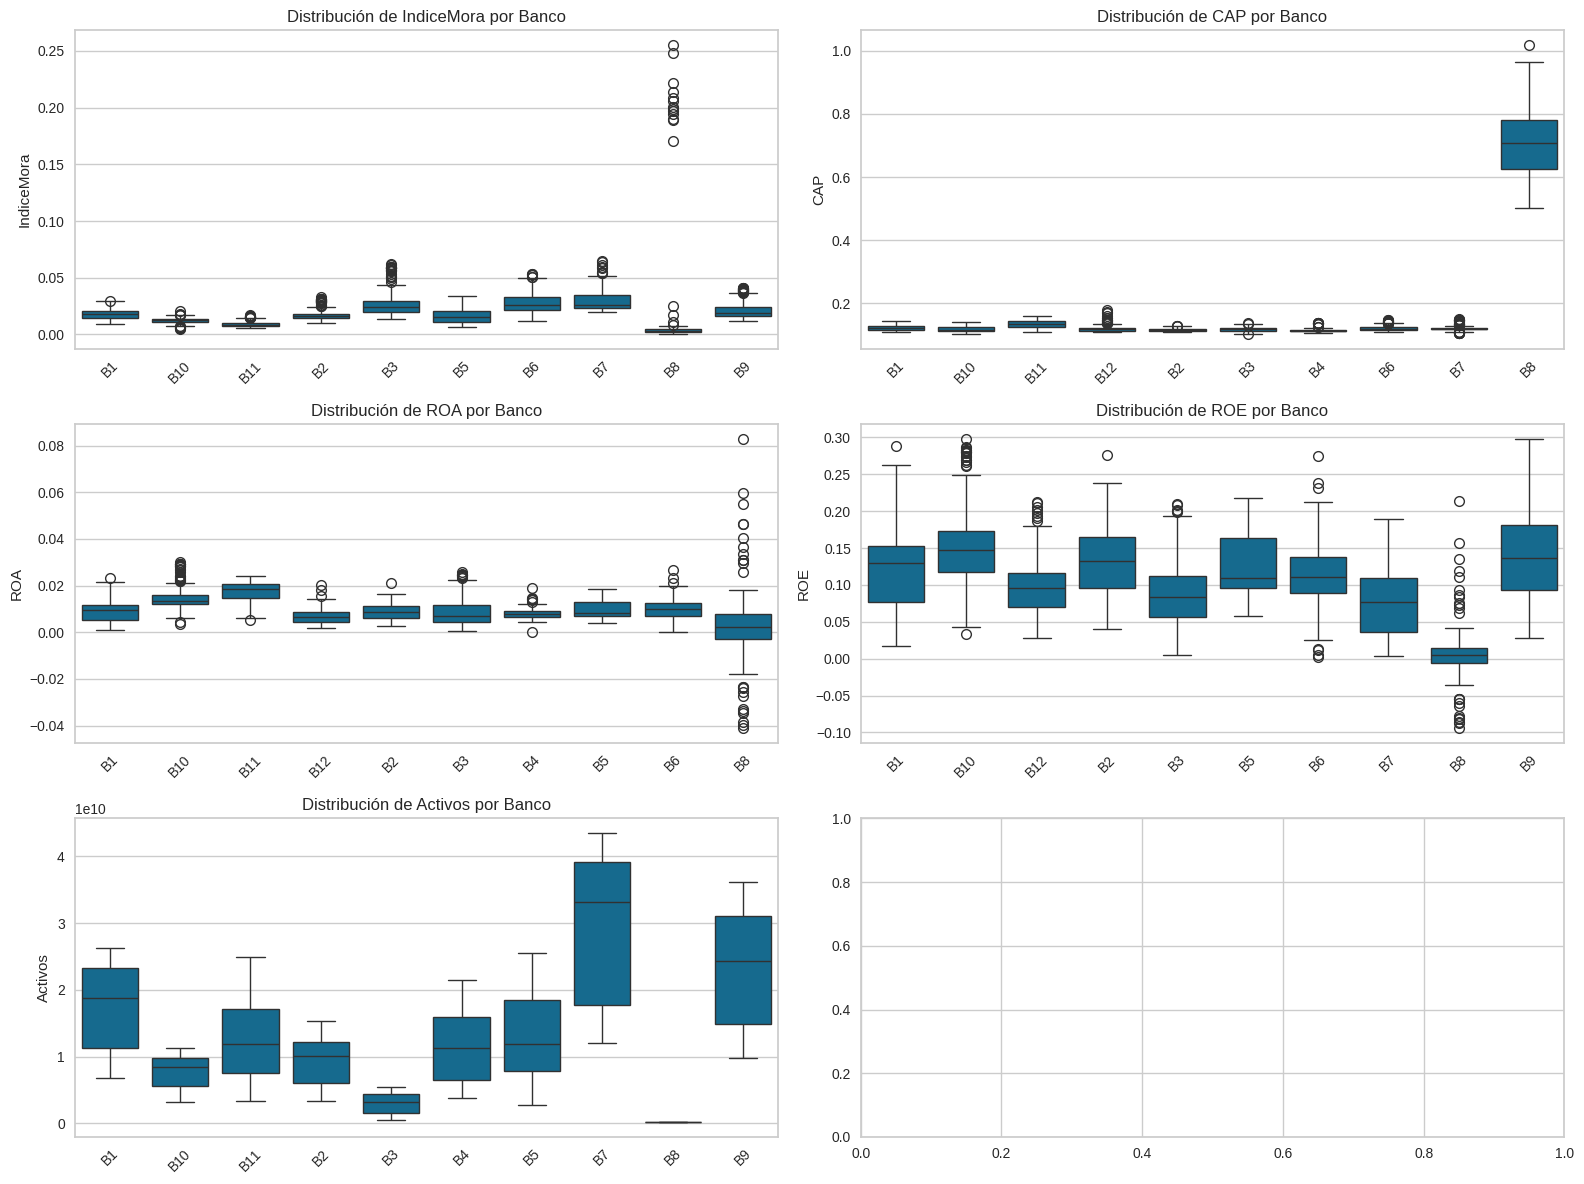

☑ Leverage
☑ Size
☑ GapCrecimiento
☑ LDR
 ⬇ Cortes fijos (train): -0.102, -0.009, 0.114, 0.273
Distribución de clases (train):
clase_riesgo
0    407
1    399
2    404
3    518
4    432
Name: count, dtype: int64
Distribución de clases (test):
clase_riesgo
0     8
1    11
2    13
3    14
4    50
Name: count, dtype: int64
✅ Datos: 2160 train, 96 test, 16 features
🚀 INICIANDO PYCARET COMPLETO
📊 Configurando PyCaret...


,Description,Value
0,Session id,42
1,Target,target
2,Target type,Multiclass
3,Original data shape,"(2256, 17)"
4,Transformed data shape,"(2686, 17)"
5,Transformed train set shape,"(2590, 17)"
6,Transformed test set shape,"(96, 17)"
7,Numeric features,16
8,Rows with missing values,3.3%
9,Preprocess,True


✅ Setup completado
🔍 Comparando modelos...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.6384,0.0000,0.6384,0.7022,0.6366,0.5232,0.5406,0.3340
lightgbm,Light Gradient Boosting Machine,0.6194,0.8854,0.6194,0.6923,0.6231,0.5020,0.5175,3.5040
gbc,Gradient Boosting Classifier,0.5801,0.0000,0.5801,0.6655,0.5830,0.4537,0.4730,8.1440
rf,Random Forest Classifier,0.5639,0.8500,0.5639,0.6559,0.5723,0.4327,0.4486,2.6420
dt,Decision Tree Classifier,0.5167,0.6947,0.5167,0.6138,0.5203,0.3754,0.3952,0.1660


Processing:   0%|          | 0/27 [00:00<?, ?it/s]

...

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6065,0.8932,0.6065,0.6853,0.6225,0.4800,0.4934
1,0.6620,0.9137,0.6620,0.7131,0.6711,0.5656,0.5774
2,0.4954,0.8722,0.4954,0.5853,0.4633,0.3701,0.3971
3,0.6875,0.9310,0.6875,0.7421,0.6984,0.5598,0.5710
4,0.8310,0.9846,0.8310,0.8490,0.8332,0.7656,0.7683
Mean,0.6565,0.9189,0.6565,0.7149,0.6577,0.5482,0.5614
Std,0.1095,0.0383,0.1095,0.0853,0.1197,0.1296,0.1223


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

📊 Evaluando modelo final...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9271,0.9987,0.9271,0.9398,0.9272,0.8909,0.8937



📈 RESULTADOS FINALES PYCARET
               Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
0  Voting Classifier    0.9271  0.9987  0.9271  0.9398  0.9272  0.8909  0.8937

📊 GENERANDO VISUALIZACIONES PYCARET
📈 1. Matriz de Confusión


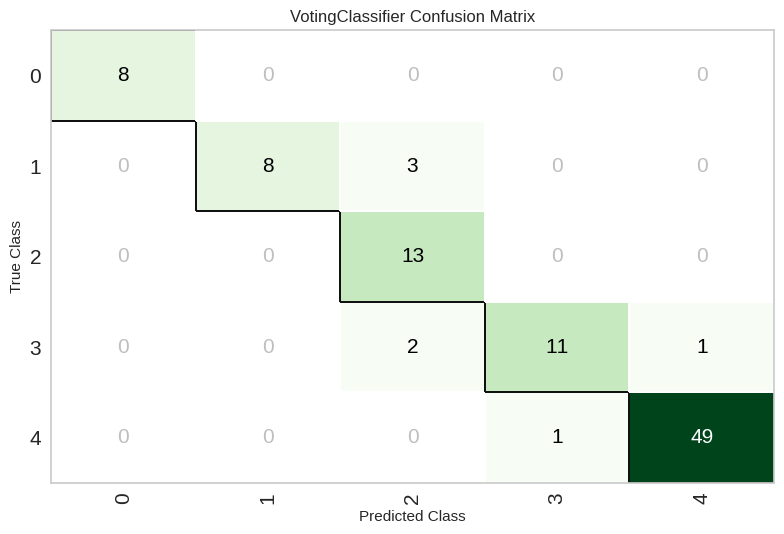

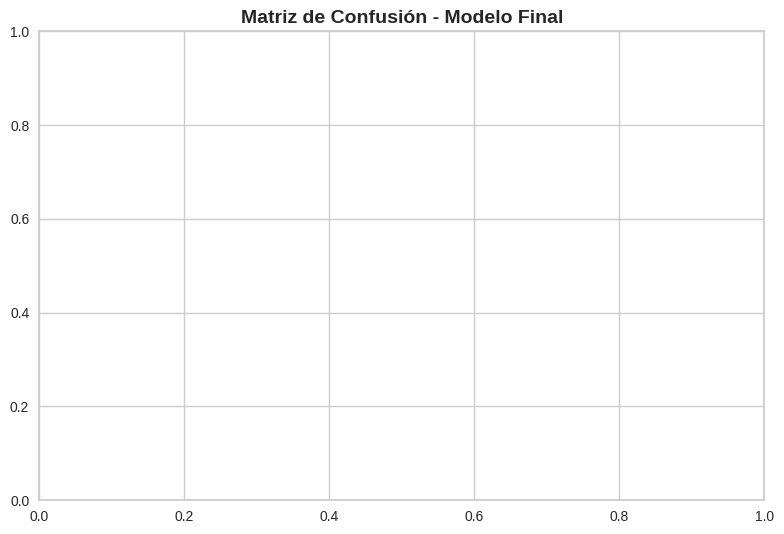

📈 2. Curva AUC


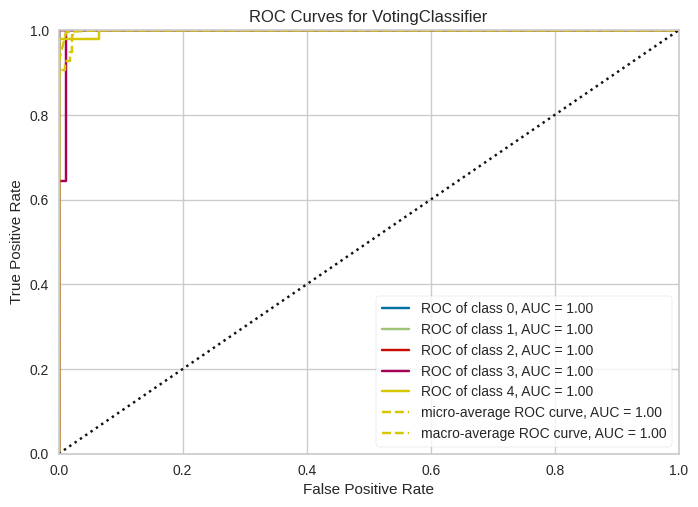

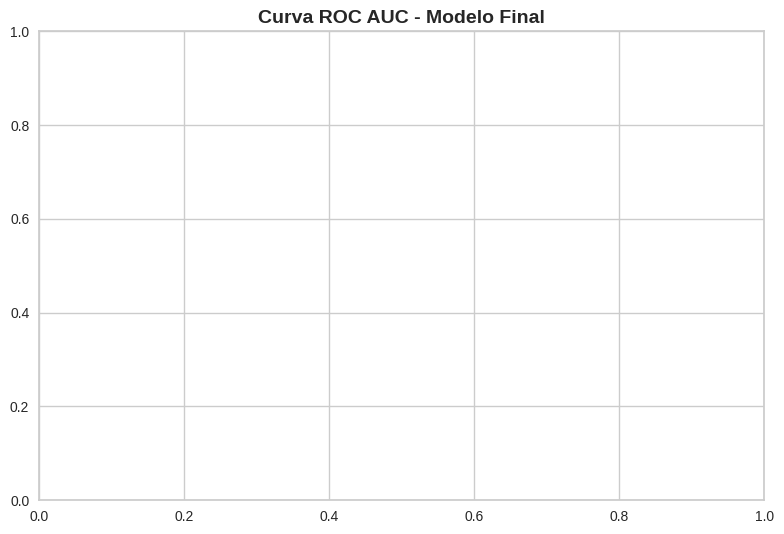

📈 3. Importancia de Características
⚠️  Error en importancia de características: Feature Importance and RFE plots not available for estimators that doesnt support coef_ or feature_importances_ attribute.
📈 4. Curva Precisión-Recall


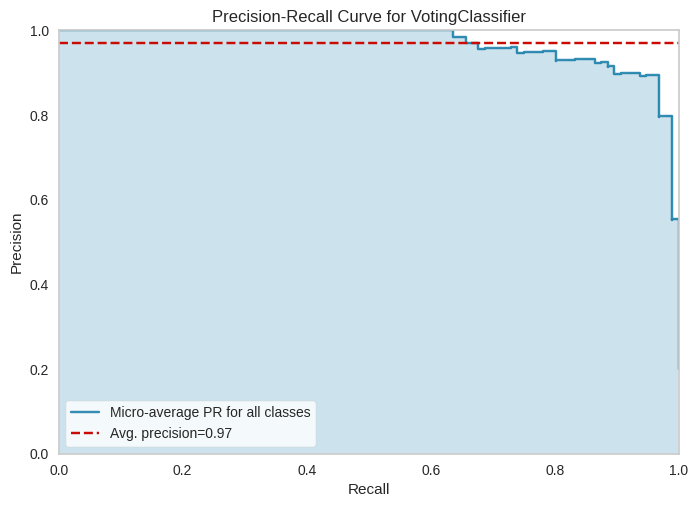

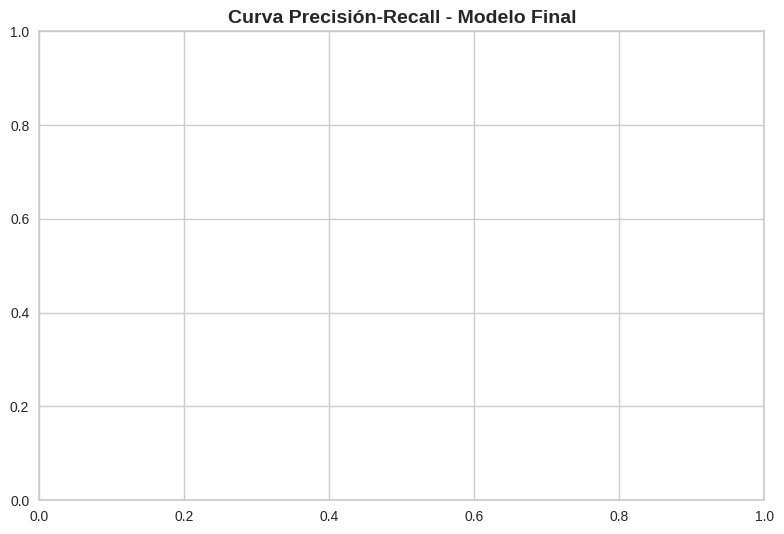

📈 5. Curva de Aprendizaje


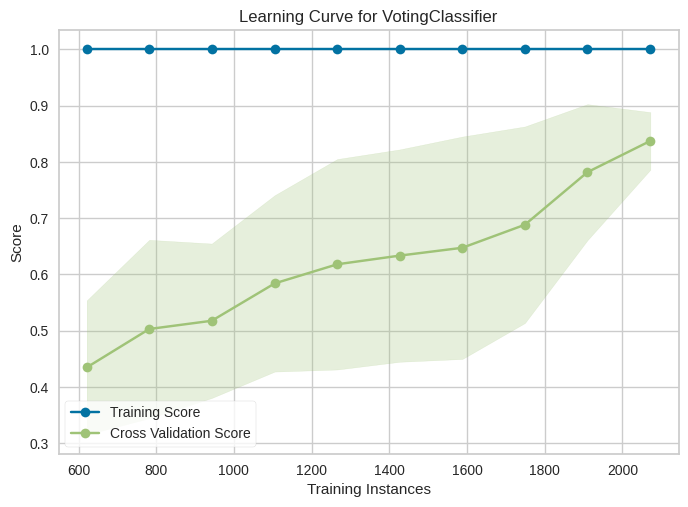

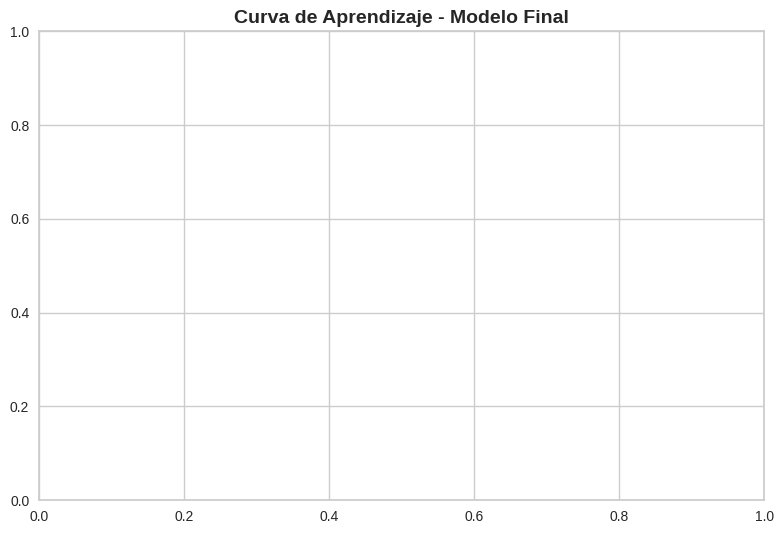

📈 6. Reporte de Clasificación


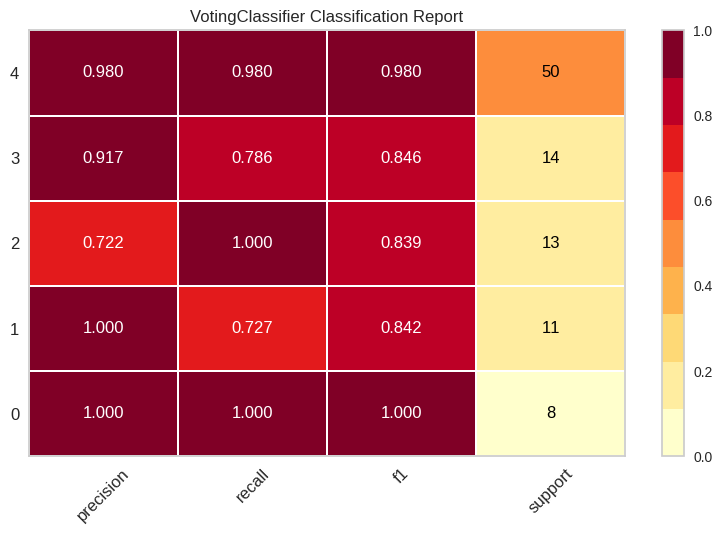

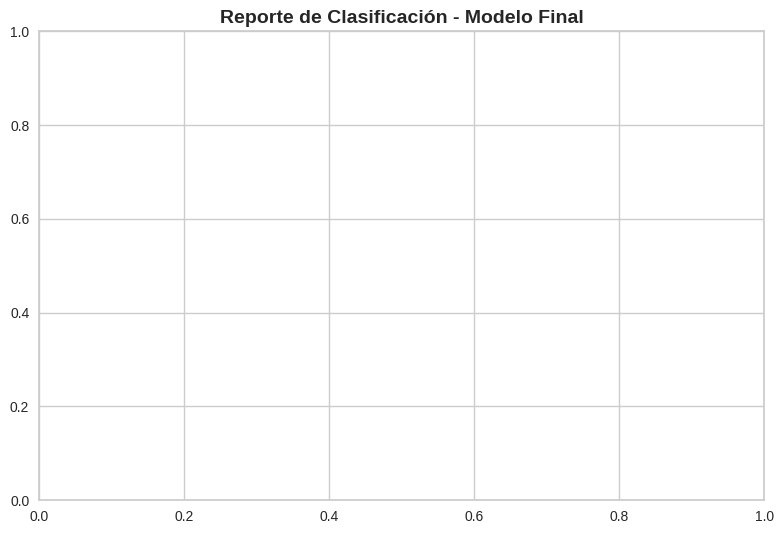

🎯 Finalizando modelo...
Transformation Pipeline and Model Successfully Saved
💾 Modelo guardado: 'modelo_riesgo_bancario_pycaret.pkl'

🔥 GENERANDO MAPA DE CALOR DE RIESGO


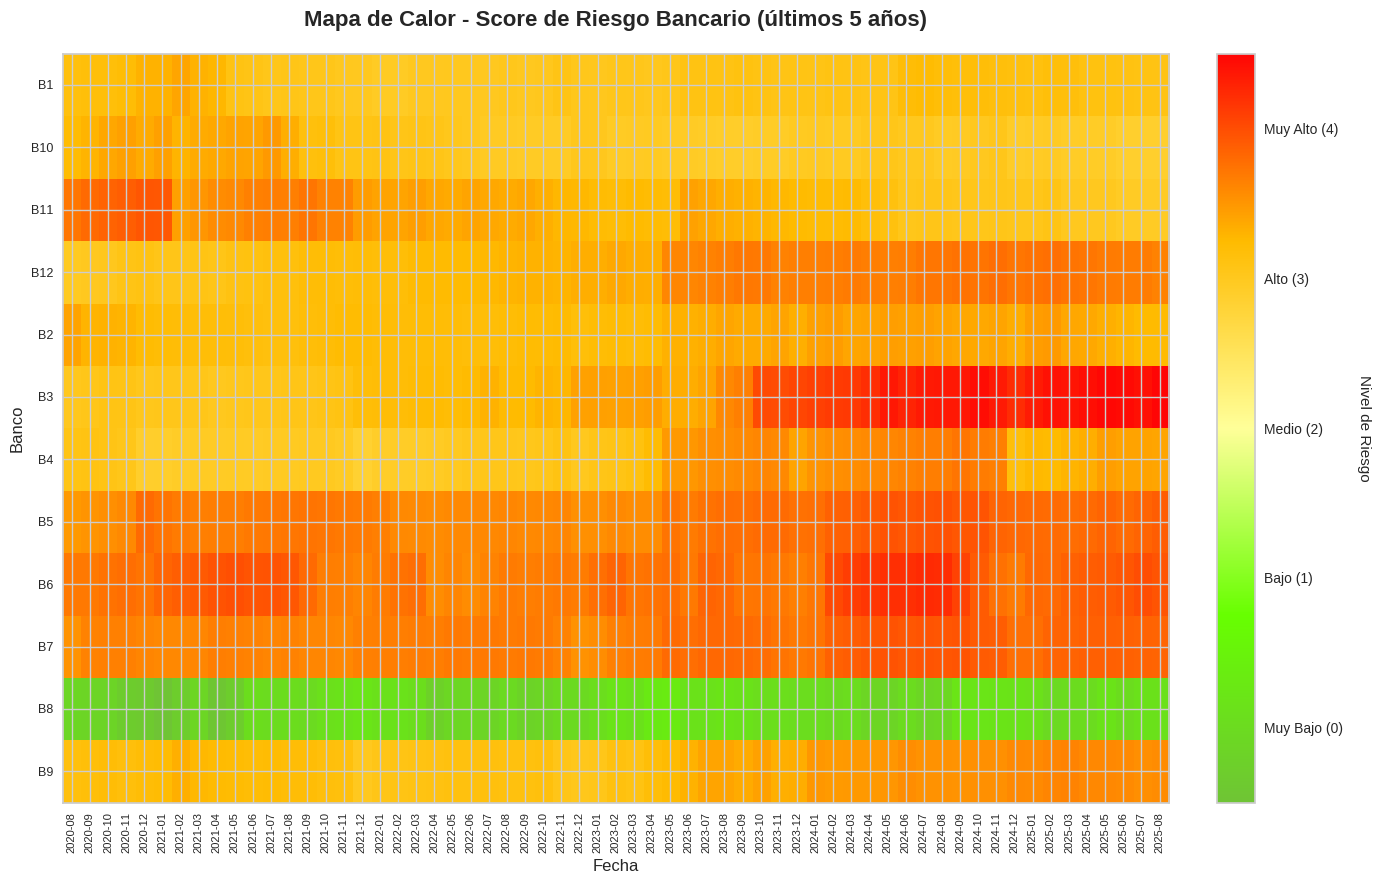


🎉 PROCESO COMPLETADO EXITOSAMENTE
✅ TODAS LAS FUNCIONALIDADES IMPLEMENTADAS:
   - EDA completo con visualizaciones
   - Modelamiento múltiple con PyCaret
   - Optimización de hiperparámetros
   - K-Fold Cross Validation (5 folds)
   - Ensemble y Stacking
   - 6 tipos de visualizaciones de modelos
   - Mapa de calor de riesgo bancario
   - Modelo guardado para producción


In [ ]:
# ---
# 8) EJECUCIÓN PRINCIPAL
# ---
def main():
    print("🔍 INICIANDO CLASIFICADOR DE RIESGO BANCARIO COMPLETO")
    print("="*70)

    # Cargar y preparar datos
    panel = crear_panel_completo(xlsx_path, VARIABLES_ESPERADAS)
    if panel is None or panel.empty:
        raise SystemExit("🔴 Panel vacío.")

    # EDA COMPLETO
    analisis_exploratorio_completo(panel)

    # Features + Score
    panel = crear_variables_derivadas(panel)
    panel = construir_score(panel)

    # Split + Etiquetar
    panel, X_train, X_test, y_train, y_test, features = split_temporal_y_etiquetar(panel)
    if X_train.empty or X_test.empty:
        raise SystemExit("🔴 Split sin datos suficientes.")

    print(f"✅ Datos: {X_train.shape[0]} train, {X_test.shape[0]} test, {len(features)} features")

    # PyCaret
    modelo_final, predictions = ejecutar_pycaret_completo(X_train, y_train, X_test, y_test)

    # Mapa de calor final
    crear_mapa_calor_riesgo(panel, ventana_anios=5)

    print("\n" + "="*70)
    print("🎉 PROCESO COMPLETADO EXITOSAMENTE")
    print("="*70)
    print("✅ TODAS LAS FUNCIONALIDADES IMPLEMENTADAS:")
    print("   - EDA completo con visualizaciones")
    print("   - Modelamiento múltiple con PyCaret")
    print("   - Optimización de hiperparámetros")
    print("   - K-Fold Cross Validation (5 folds)")
    print("   - Ensemble y Stacking")
    print("   - 6 tipos de visualizaciones de modelos")
    print("   - Mapa de calor de riesgo bancario")
    print("   - Modelo guardado para producción")

    return modelo_final, predictions, panel

# EJECUTAR
if __name__ == "__main__":
    modelo_final, predictions, panel = main()